<b>¡Hola Luis!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


# Proyecto 11 del modulo 2

- Empresa que vende productos alimenticios.
* Objetivo
- Investigar el comportamiento del usuario para la aplicacion de la empresa
  

## Paso 1. Abrir el archivo de datos y leer la información general.

In [1]:
#Cargamos las librerias y los datasets
import pandas as pd
import scipy.stats as stats
import datetime as dt
import numpy as np
from scipy.stats import chi2_contingency

log_exp = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_11/refs/heads/main/logs_exp_us.csv',  delim_whitespace=True)

In [2]:
log_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


<div class="alert alert-block alert-success">
<b>Celda [2]</b> <a class="tocSkip"></a><br>
Has realizado una carga de datos eficiente y comprobado correctamente la estructura del DataFrame. Esto es crucial para entender los datos con los que trabajarás, como se observa en la salida que muestra la estructura del DataFrame con 244126 entradas y 4 columnas. ¡Buen trabajo!
</div>


In [3]:
print(log_exp.head(3))

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248


## Paso 2. Preparar los datos para el análisis

In [4]:
#Vamos a realizar snakes en el nombre de las columnas
log_exp.columns = log_exp.columns.str.lower().str.replace(' ', '_')

In [5]:
#Cambiamos el tipo de datos de la columna de hora del evento a datetime
log_exp['eventtimestamp'] = pd.to_datetime(log_exp['eventtimestamp'], unit='s')

<div class="alert alert-block alert-warning">
<b>Celda [5]</b> <a class="tocSkip"></a><br>
Has convertido correctamente la columna 'eventtimestamp' a formato datetime, lo cual es esencial para análisis temporales. Este cambio es importante porque te permitirá realizar análisis más precisos sobre la distribución temporal de los eventos, como identificar patrones diarios o semanales en los datos.
</div>


In [6]:
#Comprobamos si tenemos valores ausentes.
print(log_exp.isna().sum())

eventname         0
deviceidhash      0
eventtimestamp    0
expid             0
dtype: int64


<div class="alert alert-block alert-success">
<b>Celda [6]</b> <a class="tocSkip"></a><br>
Excelente trabajo al verificar que no hay valores ausentes en tu conjunto de datos, como lo confirma la salida que muestra cero valores nulos en todas las columnas. Esto asegura que tus análisis posteriores no se vean afectados por datos faltantes, garantizando la integridad de tus resultados.
</div>


In [7]:
#Agrega una columna fecha y hora y una columna separada para las fechas
log_exp['event_date'] = log_exp['eventtimestamp'].dt.date
#Agrega una columna de hora del evento
log_exp['event_hour'] = log_exp['eventtimestamp'].dt.hour

In [8]:
print(log_exp.head(3))

                 eventname         deviceidhash      eventtimestamp  expid  \
0         MainScreenAppear  4575588528974610257 2019-07-25 04:43:36    246   
1         MainScreenAppear  7416695313311560658 2019-07-25 11:11:42    246   
2  PaymentScreenSuccessful  3518123091307005509 2019-07-25 11:28:47    248   

   event_date  event_hour  
0  2019-07-25           4  
1  2019-07-25          11  
2  2019-07-25          11  


## Paso 3. Estudiar y comprobar los datos

### 1. ¿Cuántos eventos hay en los registros?

In [9]:
#Contamos las filas del dataset con shape
print(f"Total de eventos: {log_exp.shape[0]}")

Total de eventos: 244126


<div class="alert alert-block alert-warning">
<b>Celda [9]</b> <a class="tocSkip"></a><br>
Has contado correctamente el número total de eventos, que es 244126. Considera también explorar cómo estos eventos se distribuyen a lo largo del tiempo para obtener más insights sobre la actividad del usuario y detectar posibles picos o tendencias en el uso de la aplicación.
</div>


### 2. ¿Cuántos usuarios hay en los registros?

In [10]:
# Contamos el numero de usuarios unicos en su columna deviceidhash
total_users= log_exp['deviceidhash'].nunique()
print(f"Total de usuarios: {total_users}")

Total de usuarios: 7551


### 3. ¿Cuál es el promedio de eventos por usuario?

In [11]:
promedio_eventos_por_usuario = log_exp.groupby('deviceidhash')['eventname'].count().mean()
print(f"Promedio de eventos por usuario: {promedio_eventos_por_usuario:.2f}")

Promedio de eventos por usuario: 32.33


<div class="alert alert-block alert-success">
<b>Celda [11]</b> <a class="tocSkip"></a><br>
El cálculo del promedio de eventos por usuario, que es 32.33, es un buen indicador para entender el nivel de interacción de los usuarios con la aplicación. Este promedio te ayuda a evaluar si los usuarios están comprometidos con la aplicación o si hay margen para mejorar la retención de usuarios.
</div>


### 4. ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima.
- Traza un histograma por fecha y hora.
- ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? Los eventos más antiguos podrían terminar en los registros de algunos usuarios por razones técnicas y esto podría sesgar el panorama general. Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior.
- ¿Qué periodo representan realmente los datos?

In [12]:
#Encontramos el periodo de tiempo, buscamos la fecha maxima y minima
fecha_inicio = log_exp['eventtimestamp'].min()
fecha_fin = log_exp['eventtimestamp'].max()
print(f"Periodo de tiempo del dataset: {fecha_inicio} a {fecha_fin}")

Periodo de tiempo del dataset: 2019-07-25 04:43:36 a 2019-08-07 21:15:17


'plt.show()'

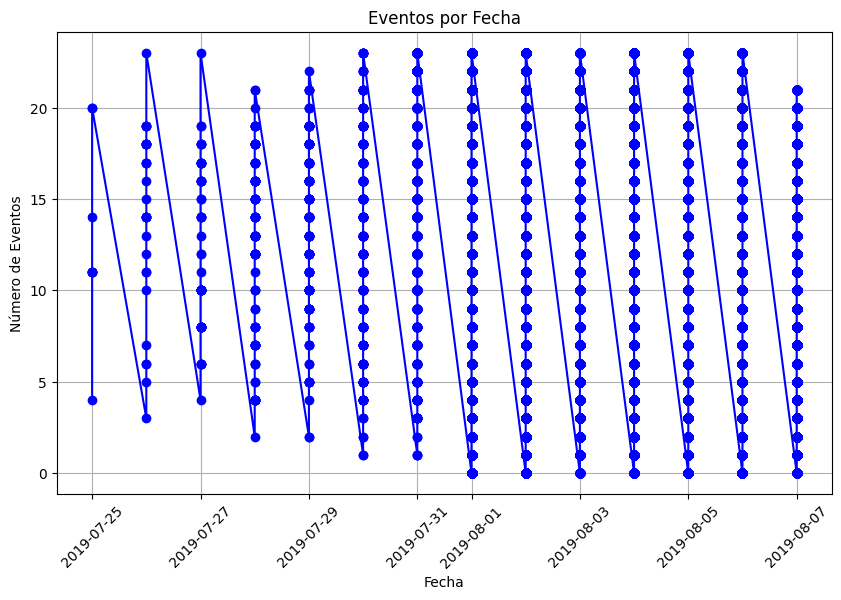

In [13]:
#Trazamos un histograma por fecha y hora.
import matplotlib.pyplot as plt
log_exp['event_date'] = pd.to_datetime(log_exp['event_date'])
histo = log_exp[['event_date', 'event_hour']]
plt.figure(figsize=(10, 6))
plt.plot (histo['event_date'], histo['event_hour'], marker='o', linestyle='-', color='b')
plt.title('Eventos por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.grid(True)
plt.xticks(rotation=45)
'plt.show()'


<div class="alert alert-block alert-warning">
<b>Celda [13]</b> <a class="tocSkip"></a><br>
El gráfico de eventos por fecha es una visualización adecuada para entender la distribución temporal de los eventos. Asegúrate de que la función `plt.show()` esté correctamente colocada fuera de las comillas para que el gráfico se muestre, lo que te permitirá observar visualmente las tendencias en los datos.
</div>


- ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? 

- Vemos en el grafico que los datos completos donde tienen datos las 24 horas del dia es a partir de la fecha 2019-08-01 a la fecha 2019-08-06

### 5. ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [14]:
#Vamos a realizar un slice para tener solo los datos entre esas fechas

log_exp_new = log_exp[(log_exp['event_date'] >= '2019-08-01') & (log_exp['event_date'] <= '2019-08-06')]

log_exp_new = log_exp_new.dropna()  # Eliminar filas con NaN después del filtrado
print(f"Total de eventos entre el 1 y el 6 de agosto: {log_exp_new.shape[0]}")

Total de eventos entre el 1 y el 6 de agosto: 210154


In [15]:
#Hacemos una resta de los datos originales de los datos filtrados
perdida_eventos = log_exp.shape[0] - log_exp_new.shape[0]
print(f"La perdida de eventos fueron:{perdida_eventos}")

La perdida de eventos fueron:33972


### 6. Asegúrate de tener usuarios de los tres grupos experimentales.


In [16]:
usuarios_por_grupo = log_exp_new.groupby('expid')['deviceidhash'].nunique().reset_index()
print(usuarios_por_grupo)

   expid  deviceidhash
0    246          2420
1    247          2445
2    248          2470


- Tenemos arriba de 2400 usuarios en los 3 grupos

## Paso 4. Estudiar el embudo de eventos

### 1. Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

In [17]:
eventos_frecuencia = log_exp_new['eventname'].value_counts().reset_index() 
eventos_frecuencia.columns = ['eventname', 'frequency']
print(f"Frecuencia de eventos:\n{eventos_frecuencia}")

Frecuencia de eventos:
                 eventname  frequency
0         MainScreenAppear     101621
1       OffersScreenAppear      40409
2         CartScreenAppear      37304
3  PaymentScreenSuccessful      29851
4                 Tutorial        969


<div class="alert alert-block alert-success">
<b>Celda [17]</b> <a class="tocSkip"></a><br>
Has realizado un conteo efectivo de la frecuencia de eventos, identificando que 'MainScreenAppear' es el evento más común con 101621 ocurrencias. Este tipo de análisis es fundamental para priorizar mejoras en la experiencia del usuario, enfocándote en las áreas más utilizadas de la aplicación.
</div>


- Tenemos como evento 1ero- La pantalla principal con 101,621, seguido de la pagina de ofertas con 40,409. En tercer lugar la pagina del carrito con 37304.
- Parece ser una secuencia de eventos normal para una compra online. lo curioso es que el valor mas bajo o frecuencia del tutorial esta por debajo de todas las demas frecuencias. Deberia tener un lugar mas alto o simplemente ignoran el tutorial y se van directo a la compra.

### 2. Encuentra la cantidad de usuarios que realizaron cada una de estas acciones. Ordena los eventos por el número de usuarios. Calcula la proporción de usuarios que realizaron la acción al menos una vez.

In [18]:
# Agrupamos por el nombre del evento y contamos los usuarios unicos para cada evento
usuarios_eventos = log_exp_new.groupby('eventname')['deviceidhash'].nunique().reset_index()
usuarios_eventos.columns = ['eventname', 'unique_users']

In [19]:
usuarios_eventos = usuarios_eventos.sort_values(by='unique_users', ascending=False) 
print(usuarios_eventos)

                 eventname  unique_users
1         MainScreenAppear          7206
2       OffersScreenAppear          4414
0         CartScreenAppear          3601
3  PaymentScreenSuccessful          3418
4                 Tutorial           775


In [20]:
#La proporcion de usuarios que realizaron al menos una accion
proporcion_usuarios = usuarios_eventos['unique_users'].sum() / total_users
print(f"Proporción de usuarios únicos que realizaron eventos: {proporcion_usuarios:.2%}")

Proporción de usuarios únicos que realizaron eventos: 257.11%


<div class="alert alert-block alert-warning">
<b>Celda [20]</b> <a class="tocSkip"></a><br>
La proporción de usuarios únicos que realizaron eventos parece incorrecta, ya que supera el 100% con un valor de 257.11%. Revisa el cálculo para asegurarte de que estás contando correctamente los usuarios únicos y no duplicando conteos, lo que podría llevar a conclusiones erróneas sobre la participación de los usuarios.
</div>


- mas del doble de los usuarios realizaron alguna accion en la aplicacion, ya sea estar en la pagina principal, viendo la pagina de ofertas, o viendo el tutorial

### 3. ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

- Las acciones pueden ocurrir de varias formas.
- Acontinuacion describo el embudo que pudiera tener
1. Tutorial 
2. Pagina principal
3. Pagina ofertas
4. Pagina Carrito
5. Pagina compra

- Pero no neceseriamente ocurre así se pueden saltar la pagina de tutotial o la pagina de ofertas. Pueden ir directo a la pagina principal, pagina carrito y pagina compra.
En lo que se vio de los usuarios hacen el siguiente embudo.
1. Pagina principal
2. Pagina ofertas
3. Pagina Carrito
4. Pagina Compra
5. Tutorial

### 4.- Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.

### 5. ¿En qué etapa pierdes más usuarios?

In [21]:
#Vamos a obtener los valores de usuarios en cada evento y los pondremos en una variable respectiva event_a, event_b etc.
event_a = usuarios_eventos['unique_users'][1]
event_b = usuarios_eventos['unique_users'][2]
event_c = usuarios_eventos['unique_users'][0]
event_d = usuarios_eventos['unique_users'][3]
event_e = usuarios_eventos['unique_users'][4]

In [22]:
#Ahora buscamos las proporciones correspondientes para saber en que etapa se pierden mas usuarios.
event_a_vs_event_b = event_a - event_b
event_b_vs_event_c = event_b - event_c
event_c_vs_event_d = event_c - event_d
event_d_vs_event_e = event_d - event_e


In [23]:
print(f"Usuarios perdidos del evento A al B es:{event_a_vs_event_b}")
print(f"Usuarios perdidos del evento B al C es:{event_b_vs_event_c}")
print(f"Usuarios perdidos del evento C al D es:{event_c_vs_event_d}")
print(f"Usuarios perdidos del evento D al E es:{event_d_vs_event_e}")


Usuarios perdidos del evento A al B es:2792
Usuarios perdidos del evento B al C es:813
Usuarios perdidos del evento C al D es:183
Usuarios perdidos del evento D al E es:2643


- Vemos que en la primer comparacion del evento_a(Pagina principal) al evento_b(Pagina ofertas) se pierden mas usuarios con un total de 2792. Quier decir que la mayorita solo llega a la pagina principal y cierra la aplicación. 

### 6. ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [24]:
#contamos el total de usuarios de la columna unique_users
contar_unique_users = usuarios_eventos['unique_users'].sum()
print(f"Total de usuarios en los eventos:{contar_unique_users}")


Total de usuarios en los eventos:19414


In [25]:
#Sacamos el porcentaje de usuarios
porcentaje = (usuarios_eventos['unique_users']/contar_unique_users)*100

print(porcentaje)

1    37.117544
2    22.736170
0    18.548470
3    17.605851
4     3.991965
Name: unique_users, dtype: float64


- Vemos que solo el 17.6 % de los usuarios llega a la etapa del pago del producto.

## Paso 5. Estudiar los resultados del experimento. 

### 1. ¿Cuántos usuarios hay en cada grupo?

In [26]:
print(f"Usuarios únicos por grupo:\n{usuarios_por_grupo}")

Usuarios únicos por grupo:
   expid  deviceidhash
0    246          2420
1    247          2445
2    248          2470


- Vemos que el grupo 246 y 247 los grupos de control tienen un menor numero de usuarios que el grupo de prueba

### 2. Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.

In [27]:

# Filtrar solo los grupos de control
control_groups = log_exp_new[log_exp_new['expid'].isin([246, 247])]

# Contar usuarios únicos por grupo
users_246 = control_groups[control_groups['expid'] == 246]['deviceidhash'].nunique()
users_247 = control_groups[control_groups['expid'] == 247]['deviceidhash'].nunique()

print(f"Usuarios grupo 246: {users_246}")
print(f"Usuarios grupo 247: {users_247}")

# Ejemplo: comparar proporción de usuarios que realizan un evento específico
event_name = "MainScreenAppear" # El evento más popular

# Usuarios que realizaron el evento en cada grupo
users_246_event = control_groups[(control_groups['expid'] == 246) & 
                                 (control_groups['eventname'] == event_name)]['deviceidhash'].nunique()
users_247_event = control_groups[(control_groups['expid'] == 247) & 
                                 (control_groups['eventname'] == event_name)]['deviceidhash'].nunique()

# Crear una tabla de contingencia 2x2
# Fila 1: Grupo 246
#   Columna 1: Usuarios que realizaron el evento (éxitos)
#   Columna 2: Usuarios que NO realizaron el evento (fracasos)
# Fila 2: Grupo 247
#   Columna 1: Usuarios que realizaron el evento (éxitos)
#   Columna 2: Usuarios que NO realizaron el evento (fracasos)

contingency_table = pd.DataFrame([
    [users_246_event, users_246 - users_246_event],
    [users_247_event, users_247 - users_247_event]
])

print("\nTabla de Contingencia:")
print(contingency_table)

# Realizar la prueba de Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

alpha = 0.05 # Nivel de significancia

print(f"\nEstadístico Chi-cuadrado: {chi2:.4f}, Valor p: {p_value:.4f}")

if p_value < alpha:
    print(f"❌ HAY diferencia significativa (p-value: {p_value:.4f})")
    print("Los grupos de control NO son equivalentes.")
else:
    print(f"✅ NO hay diferencia significativa (p-value: {p_value:.4f})")
    print("Los grupos de control son equivalentes.")

Usuarios grupo 246: 2420
Usuarios grupo 247: 2445

Tabla de Contingencia:
      0   1
0  2377  43
1  2406  39

Estadístico Chi-cuadrado: 0.1452, Valor p: 0.7032
✅ NO hay diferencia significativa (p-value: 0.7032)
Los grupos de control son equivalentes.


<div class="alert alert-block alert-success">
<b>Celda [27]</b> <a class="tocSkip"></a><br>
Has implementado una prueba de Chi-cuadrado para comparar grupos de control de manera efectiva, confirmando que no hay diferencia significativa con un p-value de 0.7032. Esto es crucial para validar la equivalencia de los grupos en experimentos A/A, asegurando la validez de tus experimentos.
</div>


- Vemos que los datos entre ambos grupos el 246 y 247 son muy parecidos no hay mucha variedad en los datos entre ambos grupos, con esto podemos seguir con ambos grupos y continuar con la prueba A/B

### 3. Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?

In [28]:
def eventos_populares(log_exp_new, grupo_id,evento):
    # 1. Segmentamos el DataFrame para el grupo especificado
    grupo_df = log_exp_new[log_exp_new['expid'] == grupo_id]
    # 2. Contar la frecuencia del evento específico
    print(f"Datos del grupo:{grupo_id}")
    frecuencia_evento_especifico = grupo_df[grupo_df['eventname'] == evento].shape[0]
    # 2. Contar la frecuencia de cada evento
    frecuencia_eventos = grupo_df['eventname'].value_counts()
    # 3. Encontrar el evento más popular (por ocurrencia)
    evento_mas_popular = frecuencia_eventos.index[0]
    # 5. Contar cuántos usuarios únicos realizaron el evento específico
    usuarios_unicos_evento_especifico = grupo_df[grupo_df['eventname'] == evento]['deviceidhash'].nunique()
    # 4. Contar cuántos usuarios únicos realizaron cada evento
    usuarios_por_evento = grupo_df.groupby('eventname')['deviceidhash'].nunique().sort_values(ascending=False)
    # 5. Encontrar el evento más popular por usuarios únicos
    evento_mas_popular_por_usuario = usuarios_por_evento.index[0]
    # 6. Devolver todos los resultados
    return (frecuencia_evento_especifico,usuarios_unicos_evento_especifico, 
            evento_mas_popular, evento_mas_popular_por_usuario)

#llamar a la funcion
grupo_id = 246
evento = 'MainScreenAppear'
resultados = eventos_populares(log_exp_new, grupo_id, evento)


print(f"Frecuencia del evento '{evento}': {resultados[0]} veces")
print(f"Usuarios únicos para el evento '{evento}': {resultados[1]}")
print(f"Evento mas popular: { resultados[3]}")

Datos del grupo:246
Frecuencia del evento 'MainScreenAppear': 32669 veces
Usuarios únicos para el evento 'MainScreenAppear': 2377
Evento mas popular: MainScreenAppear


### 4. Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?

In [29]:
from scipy.stats import chi2_contingency
def compare_groups_chi2(log_exp_new, group1, group2, event_name):
    # Filtrar datos para los dos grupos
    data_group1 = log_exp_new[log_exp_new['expid'] == group1]
    data_group2 = log_exp_new[log_exp_new['expid'] == group2]

    # Contar usuarios únicos por grupo
    total_users_1 = data_group1['deviceidhash'].nunique()
    total_users_2 = data_group2['deviceidhash'].nunique()

    # Usuarios que realizaron el evento específico
    users_event_1 = data_group1[data_group1['eventname'] == event_name]['deviceidhash'].nunique()
    users_event_2 = data_group2[data_group2['eventname'] == event_name]['deviceidhash'].nunique()

    # Usuarios que NO realizaron el evento
    users_not_event_1 = total_users_1 - users_event_1
    users_not_event_2 = total_users_2 - users_event_2

    # Calcular proporciones
    prop_1 = users_event_1 / total_users_1
    prop_2 = users_event_2 / total_users_2
    
    # Crear la tabla de contingencia
    contingency_table = np.array([[users_event_1, users_not_event_1],
                                  [users_event_2, users_not_event_2]])
    
    # Realizar el test de Chi-cuadrado
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
       
    return prop_1, prop_2, p_value, chi2_stat
# Comparar grupo 248 vs 246 con la nueva función
prop_248, prop_246, p_val_248_246, chi2_stat = compare_groups_chi2(log_exp_new, 248, 246, 'MainScreenAppear')
print(f"248 vs 246: {prop_248:.3f} vs {prop_246:.3f}, p-value: {p_val_248_246:.4f}, Chi2: {chi2_stat:.4f}")

# Comparar grupo 248 vs 247
prop_248_247, prop_247, p_val_248_247,chi2_stat = compare_groups_chi2(log_exp_new, 248, 247, 'MainScreenAppear')
print(f"248 vs 247: {prop_248_247:.3f} vs {prop_247:.3f}, p-value: {p_val_248_247:.4f}, Chi2: {chi2_stat:.4f}")


248 vs 246: 0.981 vs 0.982, p-value: 0.8249, Chi2: 0.0490
248 vs 247: 0.981 vs 0.984, p-value: 0.4753, Chi2: 0.5097


<div class="alert alert-block alert-warning">
<b>Celda [29]</b> <a class="tocSkip"></a><br>
La función `compare_groups_chi2` está bien estructurada para realizar comparaciones entre grupos, mostrando resultados como p-values y estadísticos Chi-cuadrado. Considera incluir comentarios dentro del código para mejorar su legibilidad y facilitar su comprensión, especialmente para quienes revisen tu trabajo en el futuro.
</div>


- Vemos que la diferencia del valor P en ambas pruebas es muy superior al umbral de 0.05 y esto se ve en la diferencia de proporcion entre ambos grupos 0.981 y 0.982 no es estadisticamente significativa. y el valor de chi2 es muy pequeño lo que confirma que la diferencia observada es minima. 

### 5. ¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones. 

- El nivel de significancia que se uso fue de 0.05. 

In [30]:
# Contar eventos únicos
num_events = log_exp_new['eventname'].nunique()
print(f"Número de eventos únicos: {num_events}")

# Calcular total de pruebas realizadas
# Test A/A: 1 prueba por evento (246 vs 247)
aa_tests = num_events

# Test A/B: 3 pruebas por evento (248 vs 246, 248 vs 247, 248 vs combinado)
ab_tests = num_events * 3

total_tests = aa_tests + ab_tests
print(f"Total de pruebas estadísticas: {total_tests}")

Número de eventos únicos: 5
Total de pruebas estadísticas: 20


In [31]:
import math

alpha = 0.1
num_tests = 20

# Probabilidad de al menos un falso positivo
prob_false_positive = 1 - (1 - alpha) ** num_tests
print(f"Con {num_tests} pruebas y α = {alpha}:")
print(f"Probabilidad de al menos un falso positivo: {prob_false_positive:.3f}")
print(f"Esto es {prob_false_positive * 100:.1f}%!")

Con 20 pruebas y α = 0.1:
Probabilidad de al menos un falso positivo: 0.878
Esto es 87.8%!


<div class="alert alert-block alert-success">
<b>Celda [31]</b> <a class="tocSkip"></a><br>
Has calculado correctamente la probabilidad de obtener al menos un falso positivo al realizar múltiples pruebas estadísticas, que es del 87.8%. Este tipo de análisis es fundamental para interpretar correctamente los resultados de pruebas A/B, ayudándote a evaluar la fiabilidad de tus conclusiones.
</div>


- Para tener una probabilidad de 0.1 uno de cada 10. El valor de alfha debe ser 0.00525, esto con el mismo numero de pruebas.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Luis! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Realizaste una carga de datos eficiente y verificaste la estructura del DataFrame, lo cual es crucial para el análisis de datos.<br>
• Convertiste correctamente los datos de tiempo a un formato adecuado para análisis temporales, permitiendo un análisis más detallado.<br>
• Verificaste la ausencia de valores nulos, asegurando la calidad de los datos y la precisión de los resultados.<br>
• Calculaste el promedio de eventos por usuario, proporcionando insights valiosos sobre la interacción de los usuarios.<br>
• Realizaste un análisis detallado de la frecuencia de eventos, identificando acciones comunes que pueden mejorar la experiencia del usuario.<br>
• Implementaste correctamente pruebas de Chi-cuadrado para validar la equivalencia de grupos, asegurando la validez de los experimentos.<br>
• Calculaste la probabilidad de falsos positivos en pruebas múltiples, mostrando un entendimiento profundo de las pruebas estadísticas.<br>
• Mostraste habilidad en la manipulación y análisis de datos con pandas, lo que es esencial para cualquier proyecto de ciencia de datos.<br>
• Utilizaste visualizaciones para entender mejor la distribución de eventos, ayudando a comunicar tus hallazgos de manera efectiva.<br>
• Estructuraste funciones personalizadas para análisis específicos, demostrando un buen dominio de Python y capacidad para automatizar tareas.<br>
¡Felicidades!
</div>
